# Earnings Straddle Book — Results

Two delta-neutral ATM-straddle sub-books around scheduled single-name earnings, each
normalized to &#36;100 vega per trade: **LONG the pre-announcement IV ramp** (buy ~14
calendar days before, sell the last close before the print — never holds the event) and
**SHORT the announcement crush** (sell the last close before, cover the first close
after — exactly one event night). Liquid US single names, 2017 → 2025-11.

*The two legs are different animals, and this notebook keeps them apart: the long leg is
the robust half (positive in every VIX regime); the short leg's economics concentrate
almost entirely in high-VIX regimes.*

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import datetime
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
D = Path('data')

def sh(x, ann=252):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    return float(x.mean()/x.std()*np.sqrt(ann))

pl.Config.set_tbl_cols(-1); pl.Config.set_tbl_width_chars(200)
pl.Config.set_tbl_hide_dataframe_shape(True)
plt.rcParams.update({'figure.dpi': 96, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})
daily = pl.read_parquet(D/'book_daily.parquet').sort('tradingDate')
conc = pl.read_parquet(D/'concurrency.parquet').sort('d')
vix = pl.read_parquet(D/'vix_daily.parquet').rename({'date': 'tradingDate'})
long_ = daily.filter(pl.col('side')=='long')
short_ = daily.filter(pl.col('side')=='short')
book = daily.group_by('tradingDate').agg(p=pl.col('daily_pnl').sum()).sort('tradingDate')
print(f"{daily['tradingDate'].min()} -> {daily['tradingDate'].max()} | "
      f"book active-days Sharpe {sh(book['p'].to_numpy()):+.2f}")

2017-01-03 -> 2025-11-18 | book active-days Sharpe +2.01


## 1. Performance — the two legs, kept separate

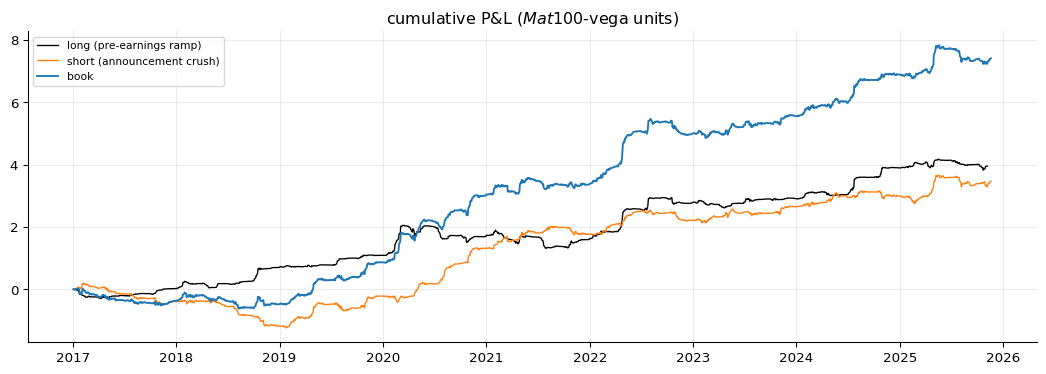

┌────────┬───────────────┬────────────────┬─────────┬─────┐
│ series ┆ sharpe_active ┆ sharpe_alldays ┆ total_M ┆ hit │
│ ---    ┆ ---           ┆ ---            ┆ ---     ┆ --- │
│ str    ┆ f64           ┆ f64            ┆ f64     ┆ str │
╞════════╪═══════════════╪════════════════╪═════════╪═════╡
│ long   ┆ 1.82          ┆ 1.61           ┆ 3.94    ┆ 52% │
│ short  ┆ 1.29          ┆ 1.18           ┆ 3.46    ┆ 59% │
│ book   ┆ 2.01          ┆ 1.91           ┆ 7.41    ┆ 55% │
└────────┴───────────────┴────────────────┴─────────┴─────┘


In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
for d, c, lab in [(long_, 'k', 'long (pre-earnings ramp)'), (short_, 'tab:orange', 'short (announcement crush)')]:
    e = d.sort('tradingDate')
    ax.plot(e['tradingDate'], e['daily_pnl'].cum_sum()/1e6, c, lw=1.0, label=lab)
bk = book.sort('tradingDate')
ax.plot(bk['tradingDate'], bk['p'].cum_sum()/1e6, 'tab:blue', lw=1.4, label='book')
ax.legend(fontsize=8); ax.set_title('cumulative P&L ($M at $100-vega units)')
plt.tight_layout(); plt.show()
from scipy import stats as st
cal = pl.DataFrame({'tradingDate': pl.date_range(book['tradingDate'].min(),
                    book['tradingDate'].max(), '1d', eager=True)}).filter(
    pl.col('tradingDate').dt.weekday() <= 5)
rows = []
for tag, d in [('long', long_.rename({'daily_pnl':'p'}).select('tradingDate','p')),
               ('short', short_.rename({'daily_pnl':'p'}).select('tradingDate','p')),
               ('book', book)]:
    x = d['p'].to_numpy()
    allday = cal.join(d, on='tradingDate', how='left').with_columns(pl.col('p').fill_null(0.0))['p'].to_numpy()
    rows.append(dict(series=tag, sharpe_active=round(sh(x), 2), sharpe_alldays=round(sh(allday), 2),
                     total_M=round(x.sum()/1e6, 2), hit=f"{np.mean(x>0):.0%}"))
print(pl.DataFrame(rows))

## 2. The regime maps — why the legs get separate verdicts

In [3]:
dv = (daily.join(vix, on='tradingDate', how='left').drop_nulls('VIX'))
for side in ('long','short'):
    d = dv.filter(pl.col('side')==side)
    d = d.with_columns(dec=d['VIX'].qcut(10, labels=[f'{i:02d}' for i in range(1,11)]))
    g = (d.group_by('dec').agg(sharpe=(pl.col('daily_pnl').mean()/pl.col('daily_pnl').std()*np.sqrt(252)).round(2)).sort('dec'))
    print(f"{side} straddle Sharpe by VIX decile:"); print(g)
    t2 = d.filter(pl.col('dec').is_in(['09','10']))['daily_pnl'].sum()
    print(f"  top-two-decile share of {side} P&L: {float(t2)/float(d['daily_pnl'].sum()):.0%}\n")
print("Concurrency (unmanaged): median", int(conc['open_long'].median()),
      "open long straddles, peak", int(conc['open_long'].max()),
      "- a registered gate before any capital.")

long straddle Sharpe by VIX decile:
┌─────┬────────┐
│ dec ┆ sharpe │
│ --- ┆ ---    │
│ cat ┆ f64    │
╞═════╪════════╡
│ 01  ┆ 2.14   │
│ 02  ┆ 3.92   │
│ 03  ┆ 4.02   │
│ 04  ┆ 3.13   │
│ 05  ┆ 1.42   │
│ 06  ┆ 0.53   │
│ 07  ┆ 1.83   │
│ 08  ┆ 2.41   │
│ 09  ┆ 1.23   │
│ 10  ┆ 0.73   │
└─────┴────────┘
  top-two-decile share of long P&L: 15%

short straddle Sharpe by VIX decile:
┌─────┬────────┐
│ dec ┆ sharpe │
│ --- ┆ ---    │
│ cat ┆ f64    │
╞═════╪════════╡
│ 01  ┆ -2.02  │
│ 02  ┆ 0.99   │
│ 03  ┆ 0.09   │
│ 04  ┆ 1.04   │
│ 05  ┆ -0.99  │
│ 06  ┆ 0.92   │
│ 07  ┆ 0.17   │
│ 08  ┆ 1.06   │
│ 09  ┆ 4.59   │
│ 10  ┆ 6.82   │
└─────┴────────┘
  top-two-decile share of short P&L: 90%

Concurrency (unmanaged): median 57 open long straddles, peak 554 - a registered gate before any capital.


## Luck check — is the realized P&L distinguishable from chance?

Two bootstrap questions. **The luck band**: 10,000 stationary-block resamples of the
realized unit returns — the spread of outcomes this stream could have delivered, and how
often such a path loses money. **The zero-edge null**: demean the units (same volatility,
no edge) — how often pure luck reaches the realized total. The first shows the width of
fortune; the second is the p-value for "it's all luck".

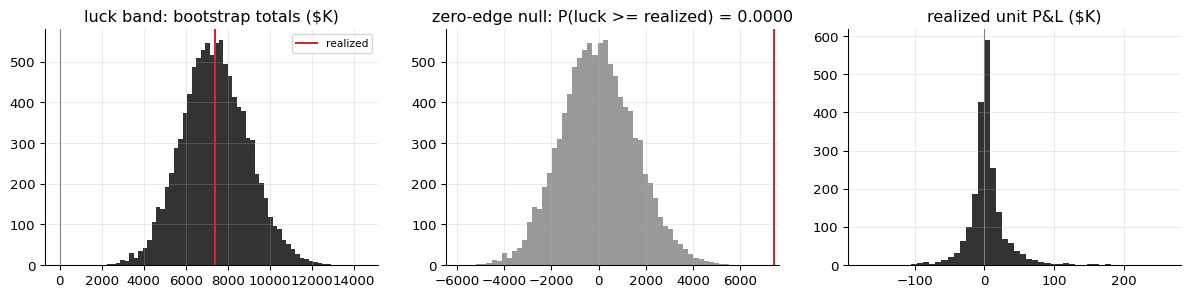

realized +7,407.4 | luck band 5th-95th [+4,858.2, +9,991.1] $K | P(path loses) = 0.00% | zero-edge p = 0.0000


In [4]:
def _block_boot(x, n_boot=10000, mean_block=3, seed=7):
    rng = np.random.default_rng(seed)
    n = len(x); p = 1.0/mean_block
    tot = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.empty(n, dtype=int)
        i = rng.integers(n)
        for k in range(n):
            idx[k] = i
            i = rng.integers(n) if rng.random() < p else (i + 1) % n
        tot[b] = x[idx].sum()
    return tot

_x = np.asarray(book['p'], float); _x = _x[~np.isnan(_x)]
_real = _x.sum(); _tot = _block_boot(_x); _null = _block_boot(_x - _x.mean())
_p = float((_null >= _real).mean())
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
ax[0].hist(_tot/1e3, bins=60, color='k', alpha=0.8)
ax[0].axvline(_real/1e3, c='tab:red', lw=1.5, label='realized')
ax[0].axvline(0, c='gray', lw=0.8); ax[0].legend(fontsize=8)
ax[0].set_title('luck band: bootstrap totals ($K)')
ax[1].hist(_null/1e3, bins=60, color='gray', alpha=0.8)
ax[1].axvline(_real/1e3, c='tab:red', lw=1.5)
ax[1].set_title(f'zero-edge null: P(luck >= realized) = {_p:.4f}')
ax[2].hist(_x/1e3, bins=50, color='k', alpha=0.8)
ax[2].axvline(0, c='gray', lw=0.8); ax[2].set_title('realized unit P&L ($K)')
plt.tight_layout(); plt.show()
print(f"realized {_real/1e3:+,.1f} | luck band 5th-95th "
      f"[{np.percentile(_tot,5)/1e3:+,.1f}, {np.percentile(_tot,95)/1e3:+,.1f}] $K | "
      f"P(path loses) = {(_tot<0).mean():.2%} | zero-edge p = {_p:.4f}")

## 3. Conclusions

- The long leg (IV ramp) is the asset: positive in every VIX regime, structural, cheap —
  though its most recent ten months graded flat, a registered watch item.
- The short leg is a high-VIX conditional (~90% of its P&L in the top two VIX deciles),
  and no cost model exists yet for sub-&#36;10 event straddles — it is not quoted as an
  all-weather book.
- The book total clears the zero-edge null; the exhibits above show the spread of
  outcomes and the unmanaged concurrency risk plainly.

*Private: universe construction, entry/exit parameter research, the sign-vintage
forensics and regeneration machinery, cost studies.*